In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import yaml
from pathlib import Path

In [2]:
exp_dir = Path("walking-controller-tests") / "nao_freq_sweep_20260128_151448"

with open(exp_dir / "metadata.yaml") as f:
    meta = yaml.safe_load(f)

test_df = pd.read_csv(exp_dir / meta["logging"]["csv_file"])
display(meta)
trials = test_df.groupby("trial_index")
test_df.head()


{'experiment_id': 'nao_freq_sweep_20260128_151448',
 'timestamp': '2026-01-28T15:14:48.733538',
 'robot': {'def_name': 'NAO',
  'type': 'NAO',
  'controller': 'WalkingMin',
  'controller_version': '0.1.0',
  'gait_templates': {'start': 'motor_patterns_smooth_start.csv',
   'walk': 'motor_patterns_continous_gait.csv',
   'stop': 'motor_patterns_smooth_stop.csv'}},
 'simulation': {'webots_version': 'R2025a',
  'world_file': 'WP2_single-robot-controller-test.wbt)',
  'basic_time_step_ms': 8,
  'notes': ''},
 'protocol': {'test_type': 'frequency_sweep_time_based',
  'frequencies_hz': [0.1, 0.5, 0.8, 1.0, 1.2, 1.3, 1.4, 1.45, 1.5, 1.55],
  'sim_duration_s': 20.0,
  'axes': {'forward': 'x', 'drift': 'y', 'height': 'z'},
  'failure_criterion': {'type': 'height_threshold',
   'height_axis': 'z',
   'threshold_m': 0.15,
   'description': 'Trial fails if min(z) < threshold at any time.'}},
 'logging': {'directory': '..\\..\\controller-testing\\walking-controller-tests\\nao_freq_sweep_20260128_15

,trial_index,step_frequency,t_abs,t_rel,x,y,z,rot_x,rot_y,rot_z,rot_angle
0,0,0.1,0.128,0.008,2.530045,0.000098,0.314587,0.000364,0.000159,1.0,3.140001
1,0,0.1,0.136,0.016,2.530109,0.000107,0.315027,0.000464,0.000173,1.0,3.140001
2,0,0.1,0.144,0.024,2.530172,0.000115,0.314835,0.000560,0.000186,1.0,3.140001
3,0,0.1,0.152,0.032,2.530237,0.000124,0.314014,0.000654,0.000200,1.0,3.140002
4,0,0.1,0.160,0.040,2.530297,0.000128,0.314426,0.000750,0.000206,1.0,3.140002


In [3]:
HEIGHT_THRESHOLD = 0.25  # meters — tune if needed

fail_records = []

for trial_index, g in trials:
    freq = g["step_frequency"].iloc[0]
    min_height = g["z"].min()
    failed = min_height < HEIGHT_THRESHOLD
    fail_records.append((trial_index, freq, min_height, failed))

fail_df = pd.DataFrame(fail_records, columns=["trial", "freq", "min_height", "failed"])
fail_df



,trial,freq,min_height,failed
0,0,0.10,0.314014,False
1,1,0.50,0.314510,False
2,2,0.80,0.315292,False
3,3,1.00,0.315937,False
4,4,1.20,0.316152,False
5,5,1.30,0.316233,False
6,6,1.40,0.315932,False
7,7,1.45,0.067992,True
8,8,1.50,0.067255,True
9,9,1.55,0.068068,True


In [ ]:
successful_trials = fail_df[~fail_df["failed"]]["trial"].tolist()
df_success = test_df[test_df["trial_index"].isin(successful_trials)]
df_success.head()
trials_success = df_success.groupby("trial_index")

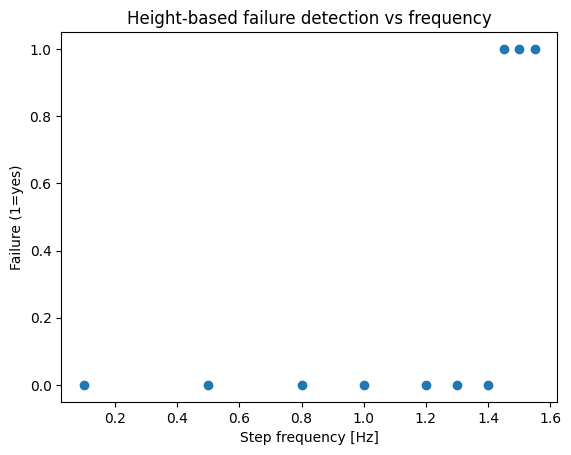

In [5]:
fig, ax = plt.subplots()
ax.scatter(fail_df["freq"], fail_df["failed"].astype(int))
ax.set_xlabel("Step frequency [Hz]")
ax.set_ylabel("Failure (1=yes)")
ax.set_title("Height-based failure detection vs frequency")
plt.show()

In [6]:
vel_records = []
for trial_index, g in trials_success:
    freq = g["step_frequency"].iloc[0]
    t = g["t_rel"].values
    x = g["x"].values
    vel = np.diff(x) / np.diff(t)
    avg_vel = vel.mean()
    vel_records.append((freq, avg_vel))

vel_df = pd.DataFrame(vel_records, columns=["freq","avg_vel"])
vel_df


,freq,avg_vel
0,0.1,-0.006189
1,0.5,-0.049640
2,0.8,-0.077956
3,1.0,-0.094453
4,1.2,-0.109125
5,1.3,-0.116287
6,1.4,-0.122869


In [7]:
drift_records = []
for trial_index, g in trials_success:
    freq = g["step_frequency"].iloc[0]
    drift = (g["y"].iloc[-1] - g["y"].iloc[0])/(g["x"].iloc[-1] - g["x"].iloc[0])
    drift_records.append((freq, drift))

drift_df = pd.DataFrame(drift_records, columns=["freq","drift"])
drift_df

,freq,drift
0,0.1,0.157901
1,0.5,-0.005443
2,0.8,-0.004251
3,1.0,0.002927
4,1.2,-0.011386
5,1.3,-0.002663
6,1.4,-0.008206


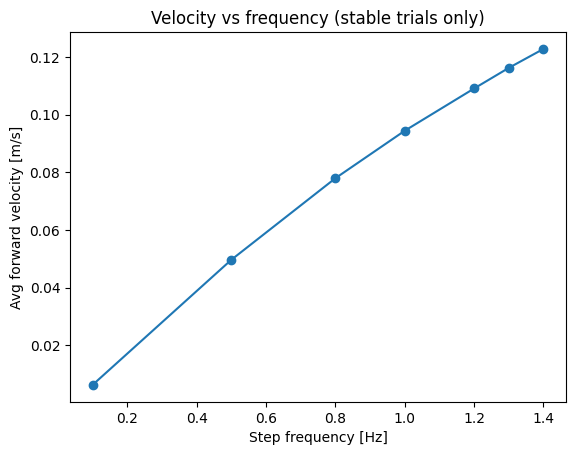

In [8]:
fig, ax = plt.subplots()
ax.plot(vel_df["freq"], vel_df["avg_vel"].abs(), "-o")
ax.set_xlabel("Step frequency [Hz]")
ax.set_ylabel("Avg forward velocity [m/s]")
ax.set_title("Velocity vs frequency (stable trials only)")
plt.show()